# MobileNet-V2 - Individual Baseline Run


In [1]:
import sys
import os

import torch

sys.path.append(os.path.abspath("../src"))

from models import MobileNetV2
from data import prepare_full_dataframe, prepare_data, sample_image_path, get_transforms
from train import run_training_pipeline, run_smoke_test
from train_eval import evaluate, predict_single_image
from utils import (
    get_device,
    get_model_path,
    plot_training_history_compact,
    plot_confusion_matrix_figure,
)
import config

print(f"Python:         {sys.executable}")
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")

Python:         c:\Users\profb\PROJECTS\cxr-model-benchmark\.venv\Scripts\python.exe
PyTorch:        2.11.0+cu128
CUDA available: True
GPU:            NVIDIA GeForce RTX 5090 Laptop GPU


In [2]:
dataset_path = config.DATASET_PATH
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print(f"Total images:    {len(df)}")
print(f"Unique patients: {df['Patient ID'].nunique()}")

Dataset location: C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays
Total images:    112120
Unique patients: 30805


In [3]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [5]:
train_loader, val_loader, test_loader = prepare_data(df)
device = get_device()

Using CUDA (GPU)


## Smoke Test


In [6]:
run_smoke_test(
    model_name="MobileNetV2",
    model_builder=lambda: MobileNetV2(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
)


=== Smoke test: MobileNetV2 (epochs=1, patience=1) ===

=== Training MobileNetV2 ===
Starting fresh training (resume disabled): c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\checkpoints\best_mobilenetv2\latest.pt
AMP enabled (bf16, grad scaler: off)
channels_last enabled
Scheduler active: type=warmup_cosine, start_epoch=1, steps_per_epoch=1, cosine_t_max=0


Train Epoch 1:   0%|          | 0/309 [00:15<?, ?it/s]

  VRAM a/r/p: 0.05G(0.2%)/2.38G(9.9%)/1.71G(7.2%)


Val Epoch 1:   0%|          | 0/66 [00:15<?, ?it/s]

Epoch 1/1 | ETA (Remaining): 00:00:00 | Total ETA: 00:02:34
  Train Loss: 0.6532 | Train Acc: 0.6241
  Val Loss: 0.6355 | Val Acc: 0.6554
  Val Precision: 0.6432
  Val Recall: 0.5492 | Val F1: 0.5925
  Val AUPRC: 0.6383
  Head LR: 1e-06
  Optimizer: AdamW | Weight Decay: 5e-05 | No-Decay Groups: 1
------------------------------------------------------------
Saved best model to c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\models\best_mobilenetv2.pt
------------------------------------------------------------


Val:   0%|          | 0/64 [00:15<?, ?it/s]

({'model': 'MobileNetV2',
  'epochs': 1,
  'batch_size': 256,
  'image_size': 256,
  'test_loss': 0.6338533461240065,
  'accuracy': 0.6608631682197156,
  'precision': 0.6583978511613209,
  'recall': 0.5528724956879395,
  'f1': 0.6010385114668975,
  'auprc': 0.6473517484390003},
 {'train_loss': [0.6532484208168926],
  'train_acc': [0.6241416879925],
  'val_loss': [0.635474475502219],
  'val_acc': [0.6554462486665876],
  'val_precision': [0.6431832014607426],
  'val_recall': [0.5492463617463618],
  'val_f1': [0.5925147182506307],
  'val_auprc': [0.6383444199570796],
  'lr': [1e-06],
  'lr_backbone': [],
  'lr_head': [1e-06],
  'backbone_frozen': [True],
  'vram_peak_pct': [7.17081075418816],
  'best_epoch': 1})

## Training


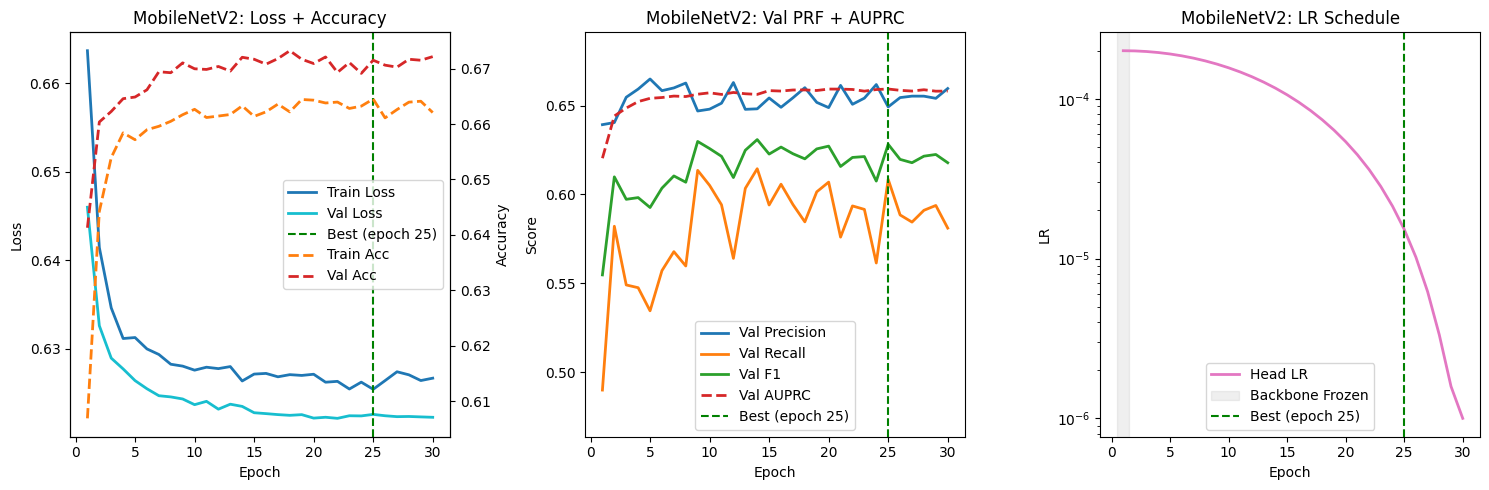

Val:   0%|          | 0/64 [00:00<?, ?it/s]

In [7]:
metrics, history = run_training_pipeline(
    model_name="MobileNetV2",
    model_builder=lambda: MobileNetV2(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=True,
)

## Results


### Val Metrics

In [8]:
# plot_training_history_compact(history, model_name="MobileNetV2")

print("\n=== Test Results ===")
print(f"Best Epoch:  {history.get('best_epoch')}")
print(f"Loss:        {metrics['test_loss']:.4f}")
print(f"Accuracy:    {metrics['accuracy']:.4f}")
print(f"Precision:   {metrics['precision']:.4f}")
print(f"Recall:      {metrics['recall']:.4f}")
print(f"F1:          {metrics['f1']:.4f}")
print(f"AUPRC:       {metrics['auprc']:.4f}")


=== Test Results ===
Best Epoch:  25
Loss:        0.6195
Accuracy:    0.6758
Precision:   0.6586
Recall:      0.6195
F1:          0.6385
AUPRC:       0.6693


### Test Metrics

Val:   0%|          | 0/64 [00:00<?, ?it/s]

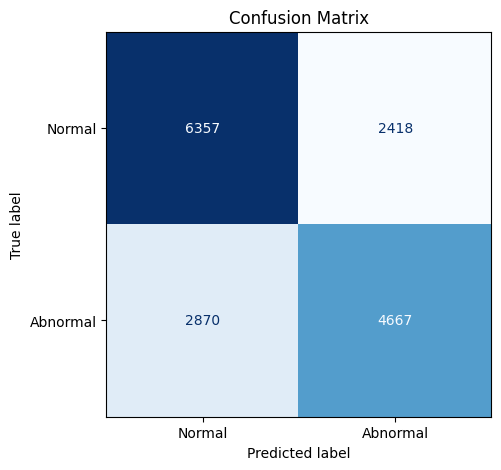

In [9]:
model = MobileNetV2(num_classes=2, in_channels=1).to(device)
model.load_state_dict(torch.load(get_model_path("best_mobilenetv2"), map_location=device))
criterion = torch.nn.CrossEntropyLoss()

_, _, _, _, _, test_labels, test_preds, _ = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

plot_confusion_matrix_figure(test_labels, test_preds, ["Normal", "Abnormal"])

In [10]:
import random

_, eval_transforms = get_transforms()
image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
result = predict_single_image(image_path, model, device, eval_transforms, df=df)

print("Image path:      ", image_path)
print("True label:      ", result["true_label"])
print("Predicted class: ", result["predicted_class"])
print("Probabilities:   ", result["probabilities"])

Image path:       C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays\images_008\images\00016560_000.png
True label:       abnormal
Predicted class:  normal
Probabilities:    {'normal': 0.5319237112998962, 'abnormal': 0.46807628870010376}
